In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Пример импорта данных

In [1]:
data = pd.read_csv('../Downloads/apple_quality.csv')

NameError: name 'pd' is not defined

## 2. Описание постановки задачи

Этот набор данных содержит информацию о различных атрибутах набора фруктов, позволяющую получить представление об их характеристиках. 
На сайте представлены две задачи:
1) Разработайте классификационную модель для классификации фруктов на основе их свойств.
2) Создайте модель для прогнозирования оценки качества фруктов с использованием различных атрибутов.

Перечисляются следующие переменные:  
- A_id: Unique identifier for each fruit
- Size: Size of the fruit
- Weight: Weight of the fruit
- Sweetness: Degree of sweetness of the fruit
- Crunchiness: Texture indicating the crunchiness of the fruit
- Juiciness: Level of juiciness of the fruit
- Ripeness: Stage of ripeness of the fruit
- Acidity: Acidity level of the fruit
- Quality: Overall quality of the fruit 

Целевой переменной является:  
- **Quality**  

Целевая переменная является дискретной, так как представлена всего 2 значениями:  
`['good', 'bad']`  
Задача бинарной классификации

## 3. Распределение целевой переменной

#### Построим гистограмму для целевой переменной:

<Axes: xlabel='Quality'>

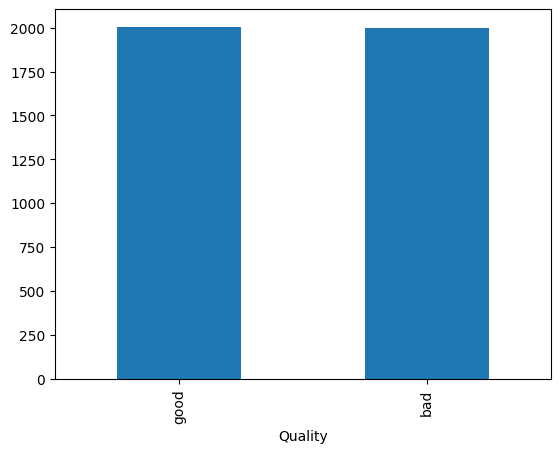

In [14]:
data['Quality'].value_counts().plot(kind='bar')

---
Из построенного графика можно заметить, что распределение однородно и значимого дисбаланса классов нет.

Количество уникальных значений целевой переменной:

In [13]:
data['Quality'].nunique()

2

## 4. Статистика по переменным

In [15]:
data.describe()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1999.500000,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277
std,1154.844867,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427
min,0.000000,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599
25%,999.750000,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677
50%,1999.500000,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445
75%,2999.250000,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212
max,3999.000000,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837


## 5. Вся информация по ДС

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


---
##### Информация, которую мы получили:  
- Набор содержит 4001 запись о фруктах с 9 колонками
- Обнаружена 1 неполная запись с пропусками в 8 из 9 столбцов
- Типы данных: float64(7), object(2)

## 6. Сколько пропусков

In [25]:
data.isna().sum()

A_id           1
Size           1
Weight         1
Sweetness      1
Crunchiness    1
Juiciness      1
Ripeness       1
Acidity        0
Quality        1
dtype: int64

In [82]:
data[data.isnull().any(axis=1)]

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Created_by_Nidula_Elgiriyewithana,NaN


---
- 4001 запись, 1 строка с пропусками в 8 из 9 признаков
- Строка 4000 - это техническая/служебная строка, а не реальные данные (Created_by_Nidula_Elgiriyewithana)
- Решением является удаление строки с пропусками, так как это не повлияет на объем данных

In [4]:
data_clean = data.drop(4000)

In [5]:
data_clean['Acidity'] = pd.to_numeric(data_clean['Acidity'])

## 7. Гистограммы 5 признаков

### №1 Признак Sweetness (Сладость)
Распределение близко к нормальному, симметричное. Пик частоты наблюдается в центральной зоне (около 0), с равномерным уменьшением частоты к краям диапазона (-6 и +6). Смещений и асимметрии не наблюдается.

<Axes: xlabel='Sweetness', ylabel='Count'>

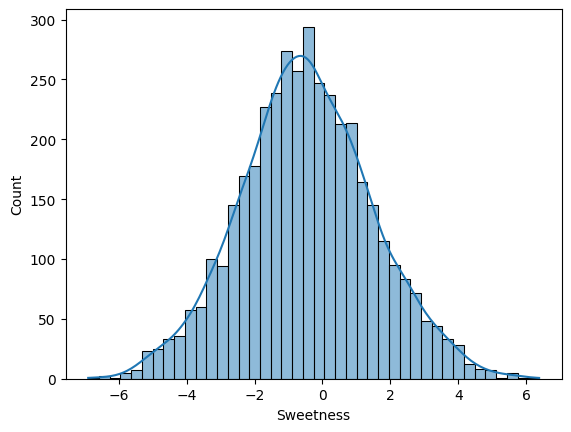

In [58]:
sns.histplot(data=data, x='Sweetness', kde=True)

### №2 Признак Crunchiness (Хрусткость)

Распределение демонстрирует смещение вправо. Пик гистограммы находится в области положительных значений (~1), а не в центре (0).   
Распределение модальное - имеет один выраженный пик, смещенный в область положительных значений.

<Axes: xlabel='Crunchiness', ylabel='Count'>

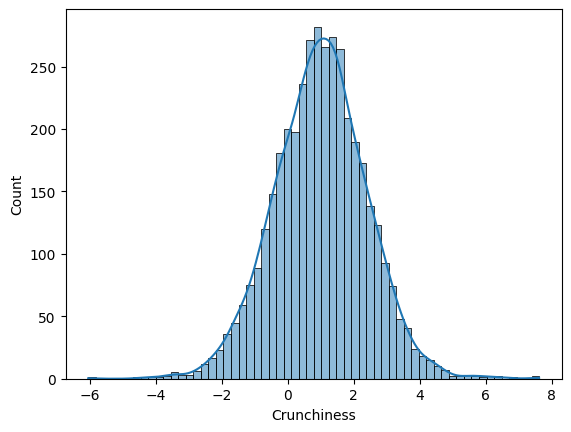

In [59]:
sns.histplot(data=data, x='Crunchiness', kde=True)

### №3 Признак Juiciness (Сочность)

Распределение близко к нормальному с незначительным смещением пика вправо (к значению ~0.5). При этом распределение остается в целом симметричным, с равномерным уменьшением частоты наблюдений к обоим краям диапазона.

<Axes: xlabel='Juiciness', ylabel='Count'>

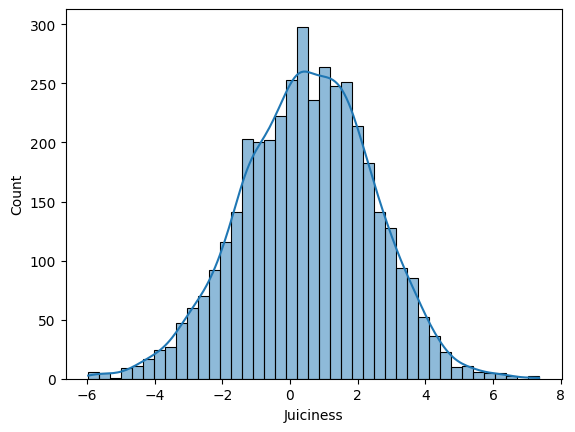

In [60]:
sns.histplot(data=data, x='Juiciness', kde=True)

### №4 Признак Ripeness (Зрелость)

Распределение демонстрирует незначительное смещение пика вправо (к значению ~0.5). При этом форма распределения остается в целом симметричной с равномерным убыванием частоты наблюдений к краям диапазона.

<Axes: xlabel='Ripeness', ylabel='Count'>

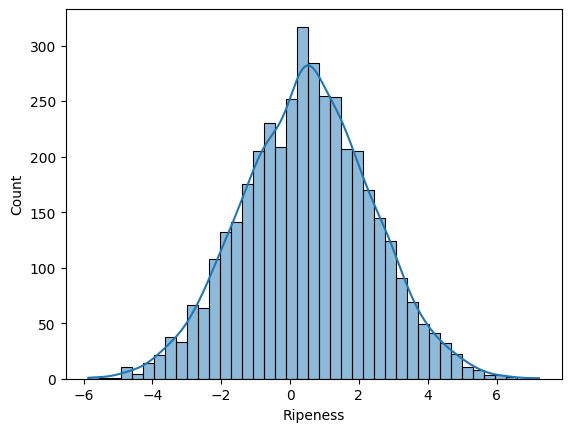

In [61]:
sns.histplot(data=data, x='Ripeness', kde=True)

### №5 Признак Acidity (Кислотность)

Распределение демонстрирует нормальное симметричное распределение с пиком в центральной зоне (около 0). Наблюдается равномерное уменьшение частоты значений по мере удаления от центра в обе стороны. Значения сосредоточены в диапазоне от -4 до +4, с редкими выбросами до -6 и +6. Смещений и асимметрии не наблюдается.

<Axes: xlabel='Acidity', ylabel='Count'>

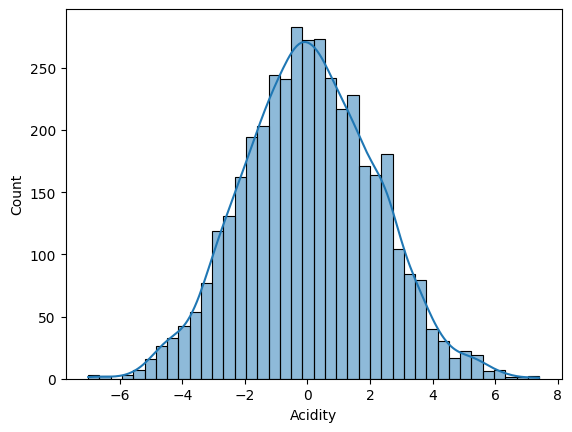

In [85]:
sns.histplot(data=data_clean, x='Acidity', kde=True)

## 8. Графики зависимости переменных с целевой

### №1 Признак Sweetness

Сладость - значимый признак. Фрукты с положительными значениями сладости с высокой вероятностью относятся к качеству `good`, а с отрицательными - к `bad`. Признак хорошо разделяет классы.

<Axes: xlabel='Quality', ylabel='Sweetness'>

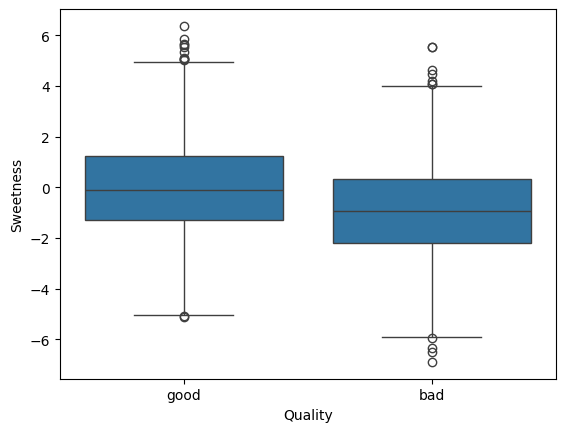

In [100]:
sns.boxplot(data=data_clean, x='Quality', y='Sweetness')

### №2 Признак Crunchiness

`Crunchiness` не показывает значимых различий между качественными и некачественными фруктами. Медианные значения и распределения практически идентичны для обоих классов, что делает этот признак малополезным для классификации.

<Axes: xlabel='Quality', ylabel='Crunchiness'>

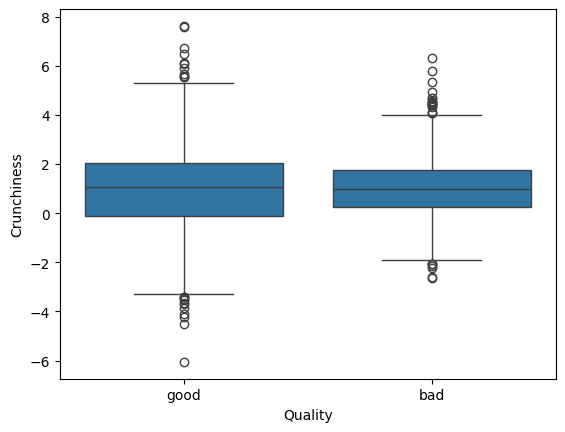

In [101]:
sns.boxplot(data=data_clean, x='Quality', y='Crunchiness')

### №3 Признак Juiciness

Juiciness влиятельый признак. Медианное значение для качественных фруктов составляет 1, тогда как для некачественных 0.

<Axes: xlabel='Quality', ylabel='Juiciness'>

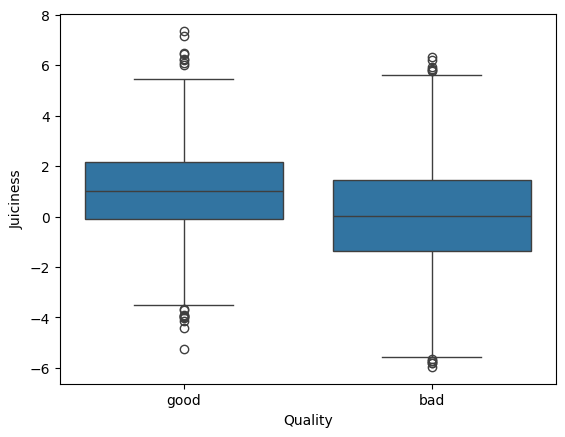

In [102]:
sns.boxplot(data=data_clean, x='Quality', y='Juiciness')

### №4 Признак Ripeness

Спелость демонстрирует обратную зависимость с качеством: медианное значение для некачественных фруктов составляет 1, тогда как для качественных 0. Это свидетельствует о том, что чрезмерная спелость негативно влияет на качество фруктов.

<Axes: xlabel='Quality', ylabel='Ripeness'>

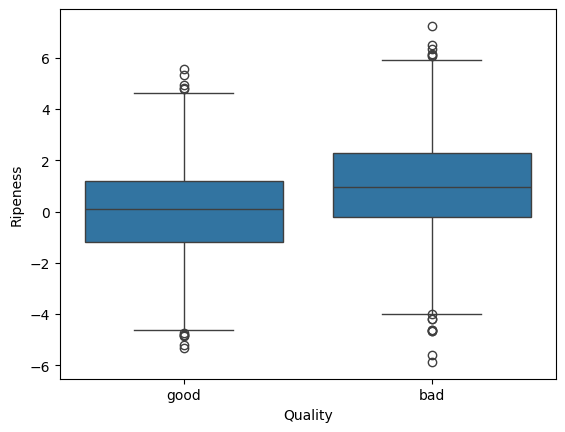

In [103]:
sns.boxplot(data=data_clean, x='Quality', y='Ripeness')

### №5 Признак Acidity

Спелость не показывает значимых различий между классами качества. Медианные значения и распределения практически идентичны для обоих категорий, что делает этот признак малополезным для классификации качества фруктов.

<Axes: xlabel='Quality', ylabel='Acidity'>

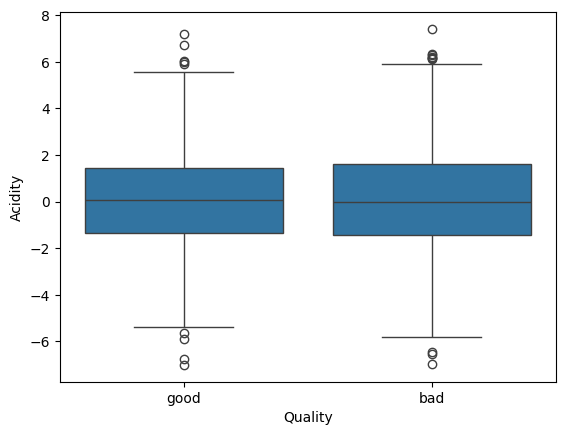

In [104]:
sns.boxplot(data=data_clean, x='Quality', y='Acidity')

In [6]:
data_clean.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good


In [8]:
replace_Quality = {'good' : 1, 'bad' : 0}

In [10]:
data_clean['Quality'] = data_clean['Quality'].map(replace_Quality)

In [12]:
X = data_clean.drop(columns='Quality')

In [13]:
y = data_clean.Quality

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
clf_rf = RandomForestClassifier()

In [19]:
parametrs = {'n_estimators' : range(10, 50, 10), 'criterion' : ['gini', 'entropy'], 'max_depth' : range(1, 14, 2)}

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
clf = GridSearchCV(clf_rf, parametrs, cv=5)

In [23]:
clf.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': range(1, 14, 2), 'n_estimators': range(10, 50, 10)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,40


In [24]:
bst_mod = clf.best_estimator_

In [28]:
feature_importances = bst_mod.feature_importances_

In [29]:
df = pd.DataFrame({'name_feat' : X_train.columns, 'feature_importances' : feature_importances})

In [33]:
sort = df.sort_values('feature_importances', ascending=False)

In [36]:
sort

,name_feat,feature_importances
6,Ripeness,0.163222
3,Sweetness,0.153853
1,Size,0.153323
5,Juiciness,0.142489
7,Acidity,0.128041
2,Weight,0.107517
4,Crunchiness,0.101734
0,A_id,0.049821


<Axes: xlabel='name_feat'>

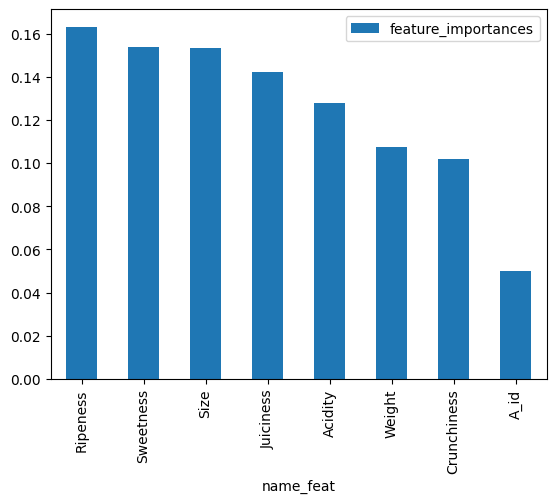

In [39]:
sort.plot(x = 'name_feat', kind = 'bar')

---
### Полная подробная информация о score модели по классам

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [81]:
score_models = bst_mod.score(X_test, y_test)

In [48]:
y_pred = bst_mod.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       401
           1       0.89      0.89      0.89       399

    accuracy                           0.89       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.89      0.89      0.89       800



---
### ROC-кривая демонстрирует отличное качество классификации (AUC = 0.96). Кривая сильно выгнута в левый верхний угол, что свидетельствует о высокой способности модели различать хорошие и плохие яблоки. Модель значительно превосходит случайное угадывание.

In [84]:
y_pred_proba = bst_mod.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.955


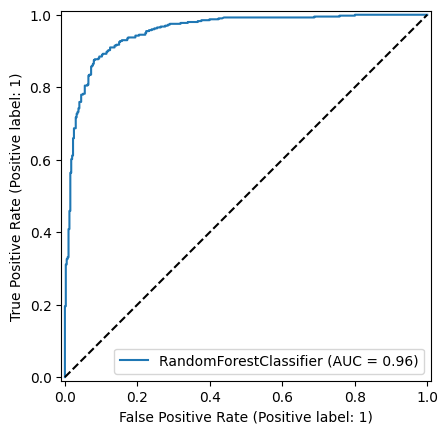

In [94]:
RocCurveDisplay.from_estimator(bst_mod, X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--') 

---
### Вывели строки с неправильно предсказанными значениями

In [57]:
errors_mask = y_pred != y_test
error_indices = X_test[errors_mask].index

data_clean.loc[error_indices]

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
555,555.0,3.099411,-1.691561,-3.679364,0.963606,0.538102,1.660099,-0.544761,1
3491,3491.0,1.439788,-0.223976,-0.061449,1.412705,0.885641,-2.191811,1.952777,0
527,527.0,1.206786,-0.508979,1.736207,1.301011,-0.556149,-1.332052,1.009156,0
70,70.0,0.610132,-3.460819,1.336759,0.387452,-0.136781,2.988646,-2.044769,0
803,803.0,-1.071853,-1.496799,-0.303023,1.425078,2.183076,1.532804,1.433817,1
...,...,...,...,...,...,...,...,...,...
254,254.0,-0.845554,1.636921,-1.397459,0.207483,-2.826070,-0.210229,0.196019,1
1061,1061.0,-0.609625,-1.747734,0.944680,2.448035,-0.397478,1.177331,1.837751,1
67,67.0,-1.569764,1.059865,1.518880,1.666096,3.068931,-1.480351,2.769459,0
2877,2877.0,-4.857230,0.918827,1.828044,1.053629,1.162220,-1.082272,0.734983,1


---
### Матрица ошибок

```
                Фактические значения
              ┌─────────────────────┐
              │   Плохие   Хорошие  │
Прогнозы     ├─────────────────────┤
модели       │ Плохие  │  TN  │ FN  │
             │ Хорошие │  FP  │ TP  │
              └─────────────────────┘
```

- TN (True Negative) — правильно предсказанные плохие яблоки
- FP (False Positive) — плохие яблоки, названные хорошими ✅
- FN (False Negative) — хорошие яблоки, названные плохими ❌
- TP (True Positive) — правильно предсказанные хорошие яблоки

In [45]:
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

Матрица ошибок:
[[355  46]
 [ 42 357]]


In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

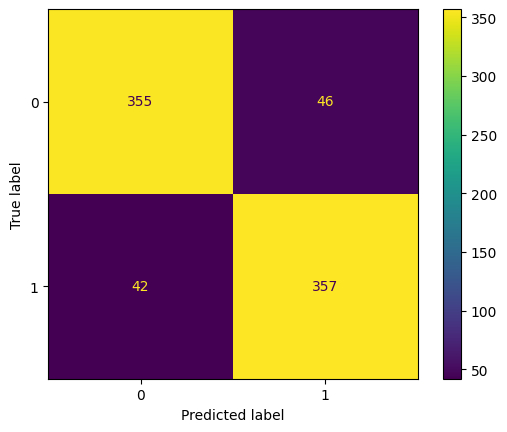

In [72]:
ConfusionMatrixDisplay.from_estimator(bst_mod, X_test, y_test)

---
### Кривая обучения показывает зависимость качества модели от объема обучающих данных. Рост кривой означает, что модель учится на новых примерах. Выход на плато свидетельствует о том, что дальнейшее увеличение данных не улучшит модель.

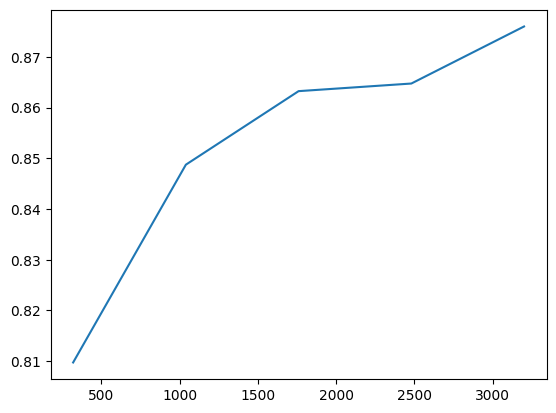

In [70]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(bst_mod, X, y)
plt.plot(train_sizes, test_scores.mean(axis=1), label='Test score')
plt.show()

---
### Baseline — это простейшая "тупая" модель для сравнения. Она показывает, какое качество было бы без машинного обучения.

In [82]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_score = baseline.score(X_test, y_test)

print(f"Baseline: {baseline_score:.3f}")
print(f"Ваша модель: {score_models:.3f}") 
print(f"Улучшение: {score_models - baseline_score:.3f}")

Baseline: 0.499
Ваша модель: 0.890
Улучшение: 0.391


### Линейная регрессия

**Линейная регрессия** — это алгоритм для прогнозирования непрерывной числовой величины (например, цены, дохода, температуры). Модель предполагает, что зависимость между целевой переменной и признаками является линейной, и находит прямую (или гиперплоскость), которая минимизирует ошибку прогноза.

*   **Задача:** **Регрессия** (прогноз числа).
*   **Результат:** Непрерывное значение.
*   **Пример:** Прогнозирование стоимости квартиры на основе её площади, района и этажа.

---

### Логистическая регрессия

**Логистическая регрессия** — это алгоритм для решения задач классификации, несмотря на название "регрессия". Модель оценивает **вероятность** принадлежности объекта к определённому классу (например, "спам" или "не спам"), используя для этого нелинейную сигмоидальную функцию.

*   **Задача:** **Классификация** (прогноз категории/класса).
*   **Результат:** Вероятность от 0 до 1.
*   **Пример:** Прогнозирование, вернётся ли клиент в банк, на основе его возраста, зарплаты и кредитной истории.